# 💳 Credit Risk Prediction System

## 📌 Objective
Predict whether a customer will default on a loan using Machine Learning.

## 🚀 Techniques Used
- XGBoost Classifier
- Feature Engineering
- SMOTE (Handling Imbalance)
- SHAP (Explainable AI)

---

In [1]:
import pandas as pd
import numpy as np
import joblib
import shap
import os

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

## 📊 Load Dataset
Loading credit risk dataset.

In [2]:
df = pd.read_csv(r"C:\Users\myesw\Downloads\cs-training.csv.csv")
df.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


## 🧹 Data Cleaning
Handling missing values and dropping unnecessary columns.

In [3]:
df.drop(columns=["Unnamed: 0"], inplace=True)

df["MonthlyIncome"] = df["MonthlyIncome"].fillna(df["MonthlyIncome"].median())
df["NumberOfDependents"] = df["NumberOfDependents"].fillna(0)

df.isnull().sum()

SeriousDlqin2yrs                        0
RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberRealEstateLoansOrLines            0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfDependents                      0
dtype: int64

## ⚙️ Feature Engineering
Creating new meaningful features.

In [4]:
df["Income_per_person"] = df["MonthlyIncome"] / (df["NumberOfDependents"] + 1)
df["Debt_per_income"] = df["DebtRatio"] / (df["MonthlyIncome"] + 1)

df["Total_Late"] = (
    df["NumberOfTime30-59DaysPastDueNotWorse"] +
    df["NumberOfTime60-89DaysPastDueNotWorse"] +
    df["NumberOfTimes90DaysLate"]
)

df.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,Income_per_person,Debt_per_income,Total_Late
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0,3040.0,8.803663e-05,2
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0,1300.0,4.685744e-05,0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0,3042.0,2.797022e-05,2
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0,3300.0,1.092084e-05,0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0,63588.0,3.919812e-07,1


## Correlation between features
Checking how features are related.

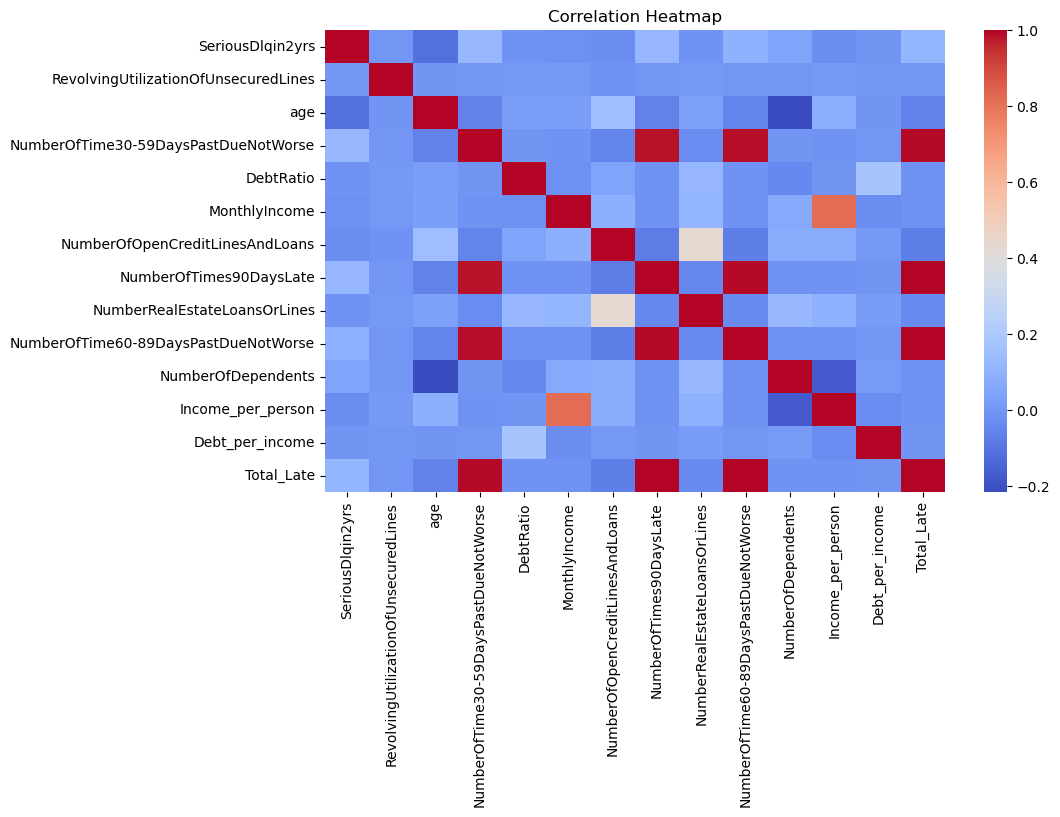

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

## 📊 Target Distribution
Checking class imbalance.

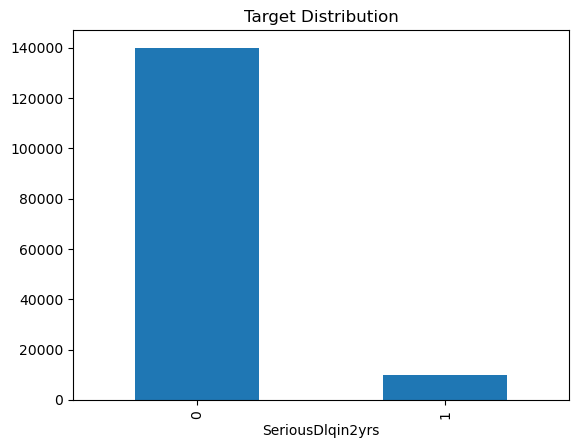

In [6]:
import matplotlib.pyplot as plt

df["SeriousDlqin2yrs"].value_counts().plot(kind="bar")
plt.title("Target Distribution")
plt.show()

## 🔀 Train-Test Split
Splitting dataset into training and testing sets.

In [7]:
X = df.drop("SeriousDlqin2yrs", axis=1)
y = df["SeriousDlqin2yrs"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## ⚖️ Handling Imbalanced Data (SMOTE)

In [8]:
smote = SMOTE()
X_train, y_train = smote.fit_resample(X_train, y_train)

## 🤖 Model Training (XGBoost)

In [9]:
model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)

model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

## 📈 Model Evaluation
Evaluating using AUC and classification report.

In [10]:
y_prob = model.predict_proba(X_test)[:, 1]

print("🔥 AUC:", roc_auc_score(y_test, y_prob))

y_pred = (y_prob > 0.6).astype(int)
print("\n📊 REPORT:\n", classification_report(y_test, y_pred))

🔥 AUC: 0.8322398409714911

📊 REPORT:
               precision    recall  f1-score   support

           0       0.97      0.87      0.92     28044
           1       0.24      0.58      0.34      1956

    accuracy                           0.86     30000
   macro avg       0.61      0.73      0.63     30000
weighted avg       0.92      0.86      0.88     30000



## Feature Importance
Top features used by the model.

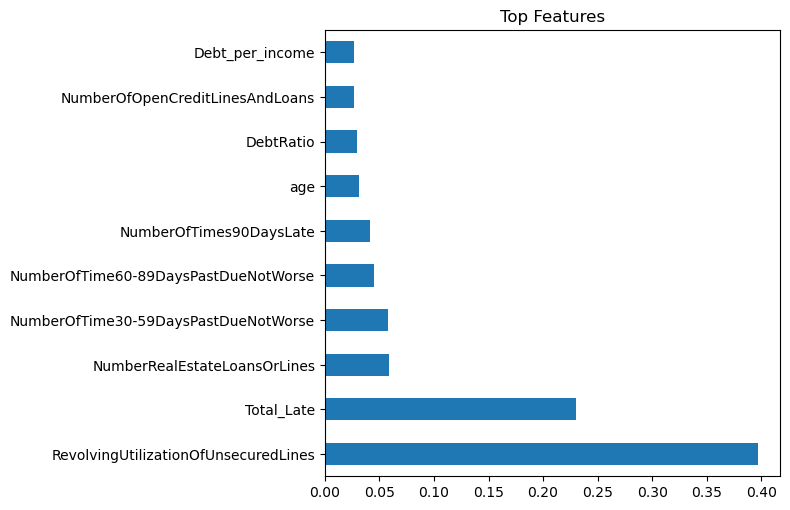

In [11]:
import pandas as pd

importances = model.feature_importances_
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False)
feat_imp.head(10).plot(kind="barh", figsize=(8,5))
plt.tight_layout()
plt.title("Top Features")
plt.show()

## Confusion Matrix
Understanding prediction performance.

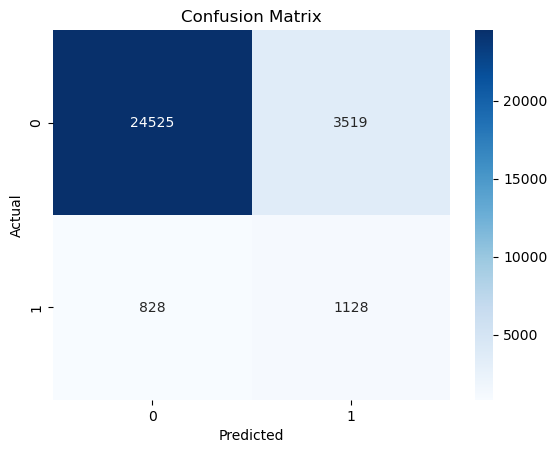

In [12]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## 💾 Save Model
Saving model and feature columns for deployment.

In [13]:
save_path = r"C:\Users\myesw\Downloads\positive_gomatha"
os.makedirs(save_path, exist_ok=True)

joblib.dump(model, os.path.join(save_path, "loan_model.pkl"))
joblib.dump(X.columns.tolist(), os.path.join(save_path, "columns.pkl"))

print("✅ Model Saved Successfully!")

✅ Model Saved Successfully!


## 🧠 Explainable AI using SHAP
Understanding feature impact on predictions.

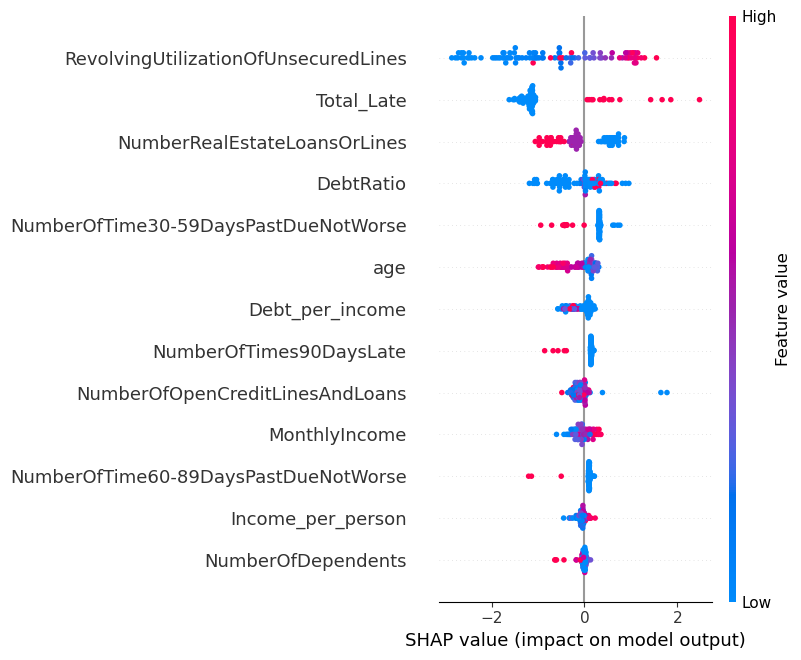

In [14]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test[:100])

shap.summary_plot(shap_values, X_test[:100])

## 🏁 Conclusion

- Model successfully predicts credit risk.
- Late payments and utilization are key factors.
- SHAP improves interpretability.

🚀 Ready for deployment using Streamlit.